###Junior Data Analyst Job Market Analysis.

In [3]:
###import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
from collections import Counter

sns.set_theme(style="whitegrid")

In [ ]:
sns.set(style="whitegrid", palette="muted")

In [4]:


df = pd.read_csv('all_job_post.csv')
print(df.shape)
print(df.columns.tolist())
df.head()


(1167, 5)
['job_id', 'category', 'job_title', 'job_description', 'job_skill_set']


,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"['employee relations', 'talent acquisition', '..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"['Talent Acquisition', 'Employee Performance M..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"['Human Resources Management', 'Recruitment', ..."
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,"['talent management', 'organizational developm..."
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,"['Microsoft Office', 'Data analysis', 'Employe..."


In [10]:
df = pd.read_csv("all_job_post.csv")

print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

df.head()

Dataset shape: (1167, 5)

Columns:
['job_id', 'category', 'job_title', 'job_description', 'job_skill_set']

Missing values:
job_id             0
category           0
job_title          0
job_description    0
job_skill_set      0
dtype: int64

Duplicate rows:
0


,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"['employee relations', 'talent acquisition', '..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"['Talent Acquisition', 'Employee Performance M..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"['Human Resources Management', 'Recruitment', ..."
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,"['talent management', 'organizational developm..."
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,"['Microsoft Office', 'Data analysis', 'Employe..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1167 entries, 0 to 1166
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           1167 non-null   int64 
 1   category         1167 non-null   object
 2   job_title        1167 non-null   object
 3   job_description  1167 non-null   object
 4   job_skill_set    1167 non-null   object
dtypes: int64(1), object(4)
memory usage: 45.7+ KB


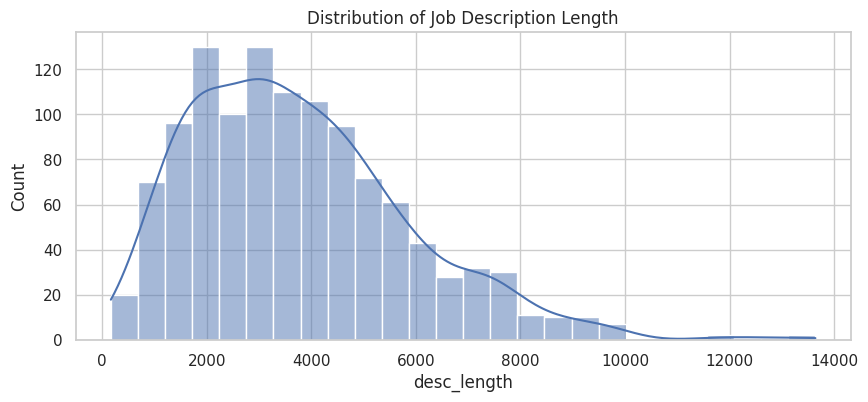

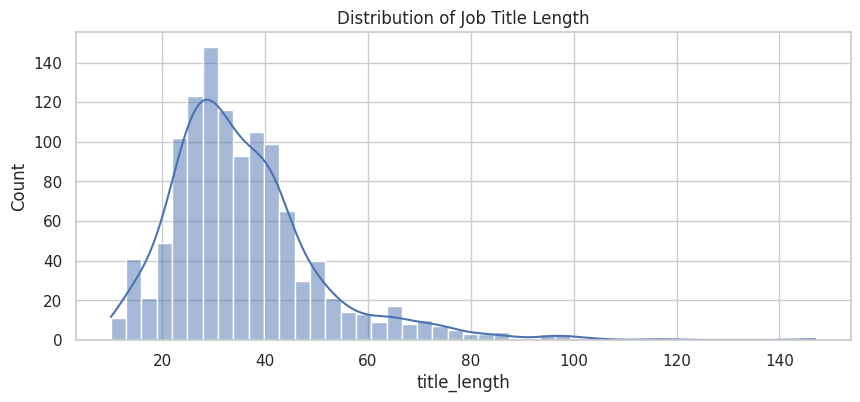

In [9]:
df["desc_length"] = df["job_description"].astype(str).apply(len)
df["title_length"] = df["job_title"].astype(str).apply(len)

plt.figure(figsize=(10,4))
sns.histplot(df["desc_length"], kde=True)
plt.title("Distribution of Job Description Length")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df["title_length"], kde=True)
plt.title("Distribution of Job Title Length")
plt.show()


In [11]:
# Normalize job_title to lower-case
df['job_title_clean'] = df['job_title'].astype(str).str.strip().str.lower()


In [12]:
# Count most common titles
title_counts = df['job_title_clean'].value_counts().head(50)
print("Top 50 job titles:\n", title_counts)

Top 50 job titles:
 job_title_clean
business development manager                     53
human resources generalist                       34
business development representative              33
human resources manager                          29
information technology support specialist        16
finance manager                                  15
human resources business partner                 15
director of finance                              13
information technology project manager           11
human resources coordinator                      11
director of information technology               10
information technology manager                   10
information technology project coordinator       10
human resources specialist                        9
sales manager                                     8
salesperson                                       8
business development specialist                   7
human resources director                          7
director of business develop

In [13]:
# Filter titles containing “data” or “analyst”
mask = df['job_title_clean'].str.contains(r'\bdata\b') | df['job_title_clean'].str.contains(r'\banalyst\b')
df_data = df[mask].copy()
print("Number of job ads with 'data' or 'analyst' in title:", df_data.shape[0])

df_data['job_title_clean'].value_counts().head(30)

Number of job ads with 'data' or 'analyst' in title: 68


,count
job_title_clean,
information technology security analyst,3
information technology business analyst,3
finance analyst,3
information technology analyst,2
information technology support analyst,2
"data engineer - enterprise data and analytics, human resources stream",1
analyst ii - information technology,1
"senior analyst, human resources technology",1
information technology system analyst,1


In [14]:
junior_keywords = ['junior', 'entry', 'intern', 'trainee', 'junior-level', 'graduate']
pattern = r'\\b(' + '|'.join(junior_keywords) + r')\\b'

df_data['is_junior_title'] = df_data['job_title_clean'].str.contains(pattern, regex=True, na=False)

print("How many 'data / analyst' ads have junior-title keyword:", df_data['is_junior_title'].sum())
print("Share:", df_data['is_junior_title'].mean())


How many 'data / analyst' ads have junior-title keyword: 0
Share: 0.0


/tmp/ipykernel_2768/2128892157.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_data['is_junior_title'] = df_data['job_title_clean'].str.contains(pattern, regex=True, na=False)


In [ ]:
# First ensure job_skill_set is string, then split; adjust delimiter if needed
df_data['job_skill_set'] = df_data['job_skill_set'].astype(str)

In [ ]:
# Some skill_sets might be in comma-separated form, or semicolon, check by inspecting first few
print(df_data['job_skill_set'].head(10))

40     ['human resources', 'microsoft office suite', ...
162    ['Global Payroll Experience', 'Global HR Exper...
194    ['Data Analysis', 'Excel', 'HR Technology', 'R...
219    ['Data Security', 'Data Management', 'Data Ana...
221    ['Communication', 'Teamwork', 'Flexibility', '...
222    ['troubleshooting', 'ticketing system', 'appli...
233    ['hardware inventory management', 'organizatio...
241    ['IT hardware support', 'application support',...
243    ['system upgrades', 'software implementation',...
261    ['Information Technology', 'Project Management...
Name: job_skill_set, dtype: object


In [ ]:
# Split skill
df_data['skills_list'] = df_data['job_skill_set'].str.split(',').apply(lambda lst: [s.strip().lower() for s in lst] if isinstance(lst, list) else [])

In [ ]:
# Explode to count skills
all_skills = df_data.explode('skills_list')['skills_list']
skill_counts = all_skills.value_counts().head(50)
print("Top required skills for data/analyst ads:\n", skill_counts)

Top required skills for data/analyst ads:
 skills_list
'communication'               63
'problem solving'             56
'teamwork'                    40
'adaptability'                36
'data analysis'               23
'attention to detail'         23
'time management'             22
'collaboration'               21
'project management'          17
'analytical skills'           17
['financial analysis'         14
'organizational skills'       14
'interpersonal skills'        13
'sql'                         12
'analytical thinking'         11
'critical thinking'           11
'customer service'            10
'microsoft excel'             10
'leadership'                  10
'financial reporting'          9
'team collaboration'           8
'independence'                 8
'financial modeling'           7
'presentation skills'          6
'excel'                        6
'troubleshooting'              6
'power bi'                     6
'reporting'                    6
'data management'    

In [ ]:
# Check if there is a column like 'date' / 'post_date' / 'posted' / 'created' etc.
print([c for c in df.columns if 'date' in c.lower() or 'post' in c.lower()])


[]


In [15]:
def parse_skills(value):
    if pd.isna(value):
        return []

    try:
        skills = ast.literal_eval(value)

        if isinstance(skills, list):
            return [
                str(skill).strip().lower()
                for skill in skills
                if str(skill).strip()
            ]

    except (ValueError, SyntaxError):
        pass

    return []


df["skills_list"] = df["job_skill_set"].apply(parse_skills)

df[["job_skill_set", "skills_list"]].head()

,job_skill_set,skills_list
0,"['employee relations', 'talent acquisition', '...","[employee relations, talent acquisition, perfo..."
1,"['Talent Acquisition', 'Employee Performance M...","[talent acquisition, employee performance mana..."
2,"['Human Resources Management', 'Recruitment', ...","[human resources management, recruitment, empl..."
3,"['talent management', 'organizational developm...","[talent management, organizational development..."
4,"['Microsoft Office', 'Data analysis', 'Employe...","[microsoft office, data analysis, employee onb..."


###Identify data/analyst-related jobs

In [16]:
data_analyst = df[
    df["job_title"].str.contains(
        r"\b(data|analyst)\b",
        case=False,
        na=False,
        regex=True
    )
].copy()

print(f"Data/analyst-related postings: {len(data_analyst)}")

Data/analyst-related postings: 68


/tmp/ipykernel_2768/3551821946.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["job_title"].str.contains(


###Examine junior-level terminology

In [17]:
junior_pattern = (
    r"\b("
    r"junior|"
    r"entry[\s-]?level|"
    r"intern|"
    r"internship|"
    r"trainee|"
    r"graduate|"
    r"new grad|"
    r"early career|"
    r"associate"
    r")\b"
)

data_analyst["junior_match"] = data_analyst["job_title"].str.contains(
    junior_pattern,
    case=False,
    na=False,
    regex=True
)

print(
    "Data/analyst postings with junior-level terminology:",
    data_analyst["junior_match"].sum()
)

Data/analyst postings with junior-level terminology: 0


/tmp/ipykernel_2768/3440221741.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  data_analyst["junior_match"] = data_analyst["job_title"].str.contains(


###Analyse the requested skills

In [18]:
skill_counter = Counter(
    skill
    for skills in data_analyst["skills_list"]
    for skill in skills
)

top_skills = pd.DataFrame(
    skill_counter.most_common(15),
    columns=["Skill", "Job_Postings"]
)

top_skills

,Skill,Job_Postings
0,communication,65
1,problem solving,56
2,teamwork,40
3,adaptability,38
4,data analysis,26
5,attention to detail,24
6,time management,24
7,collaboration,21
8,project management,19
9,financial analysis,18


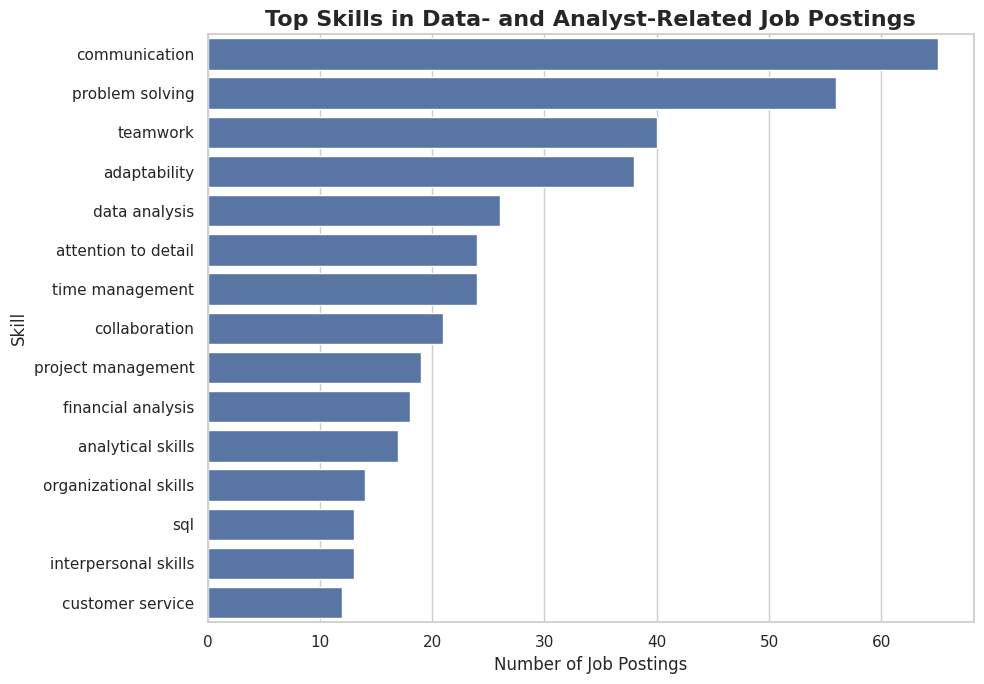

In [22]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_skills,
    x="Job_Postings",
    y="Skill"
)

plt.title(
    "Top Skills in Data- and Analyst-Related Job Postings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.tight_layout()
plt.savefig(
    "top-skills.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

###technical skills

In [20]:
technical_skills = [
    "python",
    "sql",
    "microsoft excel",
    "excel",
    "power bi",
    "data analysis",
    "data visualization",
    "tableau"
]

technical_results = []

for skill in technical_skills:
    count = skill_counter.get(skill, 0)

    technical_results.append({
        "Skill": skill.title(),
        "Job_Postings": count
    })

technical_df = (
    pd.DataFrame(technical_results)
    .sort_values("Job_Postings", ascending=False)
)

technical_df

,Skill,Job_Postings
5,Data Analysis,26
1,Sql,13
2,Microsoft Excel,11
3,Excel,6
4,Power Bi,6
0,Python,5
6,Data Visualization,5
7,Tableau,2


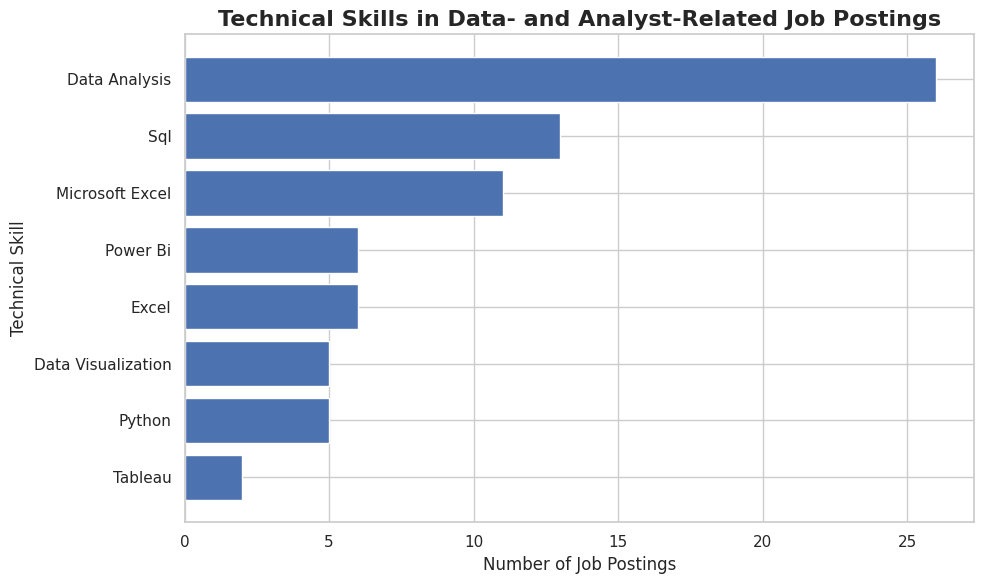

In [23]:
# Technical skills to highlight
technical_skills = [
    "python",
    "sql",
    "microsoft excel",
    "excel",
    "power bi",
    "data analysis",
    "data visualization",
    "tableau"
]

# Get the number of job postings mentioning each technical skill
technical_results = []

for skill in technical_skills:
    count = skill_counter.get(skill, 0)
    technical_results.append({
        "Skill": skill.title(),
        "Job_Postings": count
    })

technical_df = pd.DataFrame(technical_results)

# Sort from highest to lowest
technical_df = technical_df.sort_values(
    "Job_Postings",
    ascending=True
)

# Create chart
plt.figure(figsize=(10, 6))

plt.barh(
    technical_df["Skill"],
    technical_df["Job_Postings"]
)

plt.title(
    "Technical Skills in Data- and Analyst-Related Job Postings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Technical Skill")

plt.tight_layout()
plt.savefig(
    "technical-skills.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [24]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'technical-skills.png', 'top-skills.png', 'all_job_post.csv', 'sample_data']


In [25]:
from google.colab import files

files.download("top-skills.png")
files.download("technical-skills.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>